In [1]:
!pip install Unidecode

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 235.8/235.8 kB 7.2 MB/s eta 0:00:00


In [2]:
!pip install wordcloud

In [3]:
!pip install lime

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 8.1 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for lime: filename=lime-0.2.0.1-py3-none-any.whl size=283834 sha256=1939c66323c114ac05f3a2b7fce906b0f648bd2ee0ca36eff22da9c94903271c
  Stored in directory: /root/.cache/pip/wheels/e7/5d/0e/4b4fff9a47468fed5633211fb3b76d1db43fe806a17fb7486a
Successfully built lime


In [4]:
!pip install transformers

In [5]:
import warnings
warnings.filterwarnings("ignore")

In [6]:
# text preprocessing libraries
import re
import nltk
import pandas as pd
import numpy as np

from string import punctuation
from unidecode import unidecode
from nltk.corpus import stopwords
from nltk import sent_tokenize, word_tokenize

In [7]:
import matplotlib.pyplot as plt

from wordcloud import WordCloud

In [8]:
# text classification libraries
import seaborn as sns

from lime.lime_text import LimeTextExplainer
from sklearn.model_selection import train_test_split
from imblearn.under_sampling import RandomUnderSampler
from transformers import BertTokenizer, BertForSequenceClassification

# Loading data

In [9]:
url = 'https://docs.google.com/spreadsheets/d/1MaxiOZdpysqqEgBKXW1ISOGVAMOirpgm/edit?usp=sharing&ouid=117999606608884179014&rtpof=true&sd=true'
file_id = url.split('/')[-2]
read_url='https://drive.google.com/uc?id=' + file_id

data_set = pd.read_excel(read_url, index_col=False)

condition = [
    data_set["rotulo_humano"] == "sem_sintoma", # 0
    data_set["rotulo_humano"] == "sintoma" # 1
    # data_set["rotulo_vader"] == "positivo", # 2
]

values = [0, 1]

data_set["classification"] = np.select(condition, values)

data_set

,Texto,rotulo_humano,rotulo_vader,interpretacao_rotulo_vader,vader_metricas,classification
0,Aos poucos to sendo consumida por uma onda de ...,sintoma,neutro,sem_sintoma,"{'neg': 0.0, 'neu': 1.0, 'pos': 0.0, 'compound...",1
1,Nem acredito que consegui responder as mensage...,sintoma,neutro,sem_sintoma,"{'neg': 0.0, 'neu': 1.0, 'pos': 0.0, 'compound...",1
2,"tem tempo q eu n me sentia estressado assim, a...",sintoma,neutro,sem_sintoma,"{'neg': 0.0, 'neu': 1.0, 'pos': 0.0, 'compound...",1
3,A depressão carcome o cara mt coisa,sintoma,neutro,sem_sintoma,"{'neg': 0.0, 'neu': 1.0, 'pos': 0.0, 'compound...",1
4,acabei de me assustar com a minha própria anie...,sintoma,neutro,sem_sintoma,"{'neg': 0.0, 'neu': 1.0, 'pos': 0.0, 'compound...",1
...,...,...,...,...,...,...
2647,tive uma consulta tão maravilhosa ontem com mi...,sem_sintoma,neutro,sem_sintoma,"{'neg': 0.0, 'neu': 1.0, 'pos': 0.0, 'compound...",0
2648,"Crise?\nLançamentos de imóveis sobem 18,6% em ...",sem_sintoma,neutro,sem_sintoma,"{'neg': 0.0, 'neu': 1.0, 'pos': 0.0, 'compound...",0
2649,Ontem o prof de natação deu um treino de resis...,sem_sintoma,neutro,sem_sintoma,"{'neg': 0.0, 'neu': 1.0, 'pos': 0.0, 'compound...",0
2650,A urticária colinérgica é um tipo de alergia i...,sem_sintoma,neutro,sem_sintoma,"{'neg': 0.0, 'neu': 1.0, 'pos': 0.0, 'compound...",0


# Data pre-processing

In [10]:
nltk.download("rslp")
nltk.download("stopwords")
stopwords_list = stopwords.words("portuguese")
print(stopwords_list)

[nltk_data] Downloading package rslp to /root/nltk_data...
[nltk_data]   Unzipping stemmers/rslp.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...


['a', 'à', 'ao', 'aos', 'aquela', 'aquelas', 'aquele', 'aqueles', 'aquilo', 'as', 'às', 'até', 'com', 'como', 'da', 'das', 'de', 'dela', 'delas', 'dele', 'deles', 'depois', 'do', 'dos', 'e', 'é', 'ela', 'elas', 'ele', 'eles', 'em', 'entre', 'era', 'eram', 'éramos', 'essa', 'essas', 'esse', 'esses', 'esta', 'está', 'estamos', 'estão', 'estar', 'estas', 'estava', 'estavam', 'estávamos', 'este', 'esteja', 'estejam', 'estejamos', 'estes', 'esteve', 'estive', 'estivemos', 'estiver', 'estivera', 'estiveram', 'estivéramos', 'estiverem', 'estivermos', 'estivesse', 'estivessem', 'estivéssemos', 'estou', 'eu', 'foi', 'fomos', 'for', 'fora', 'foram', 'fôramos', 'forem', 'formos', 'fosse', 'fossem', 'fôssemos', 'fui', 'há', 'haja', 'hajam', 'hajamos', 'hão', 'havemos', 'haver', 'hei', 'houve', 'houvemos', 'houver', 'houvera', 'houverá', 'houveram', 'houvéramos', 'houverão', 'houverei', 'houverem', 'houveremos', 'houveria', 'houveriam', 'houveríamos', 'houvermos', 'houvesse', 'houvessem', 'houvésse

[nltk_data]   Unzipping corpora/stopwords.zip.


In [11]:
data_process = data_set.copy()
data_process.columns

Index(['Texto', 'rotulo_humano', 'rotulo_vader', 'interpretacao_rotulo_vader',
       'vader_metricas', 'classification'],
      dtype='object')

In [12]:
old_texts = data_process["Texto"]
new_texts = []

for text in old_texts:
  text = str(text).lower()
  text = re.sub('@[^\s]+', '', text)
  text = unidecode(text)
  text = re.sub('<[^<]+?>','', text)
  text = ''.join(c for c in text if not c.isdigit())
  text = re.sub('((www\.[^\s]+)|(https?://[^\s]+)|(http?://[^\s]+))', '', text)
  text = ''.join(c for c in text if c not in punctuation)
  text = ' '.join([word for word in text.split() if word not in stopwords_list])
  text = ''.join(text.replace("\"", ""))
  text = ''.join(text.replace("'", ""))
  new_texts.append(text)

data_process["Texto"] = new_texts
data_process.head()


,Texto,rotulo_humano,rotulo_vader,interpretacao_rotulo_vader,vader_metricas,classification
0,poucos to sendo consumida onda tristeza absurd...,sintoma,neutro,sem_sintoma,"{'neg': 0.0, 'neu': 1.0, 'pos': 0.0, 'compound...",1
1,acredito consegui responder mensagens maior di...,sintoma,neutro,sem_sintoma,"{'neg': 0.0, 'neu': 1.0, 'pos': 0.0, 'compound...",1
2,tempo q n sentia estressado assim agonia ansie...,sintoma,neutro,sem_sintoma,"{'neg': 0.0, 'neu': 1.0, 'pos': 0.0, 'compound...",1
3,depressao carcome cara mt coisa,sintoma,neutro,sem_sintoma,"{'neg': 0.0, 'neu': 1.0, 'pos': 0.0, 'compound...",1
4,acabei assustar propria aniedadw social pq vi ...,sintoma,neutro,sem_sintoma,"{'neg': 0.0, 'neu': 1.0, 'pos': 0.0, 'compound...",1


# Dataset balancing

<Axes: xlabel='rotulo_humano', ylabel='count'>

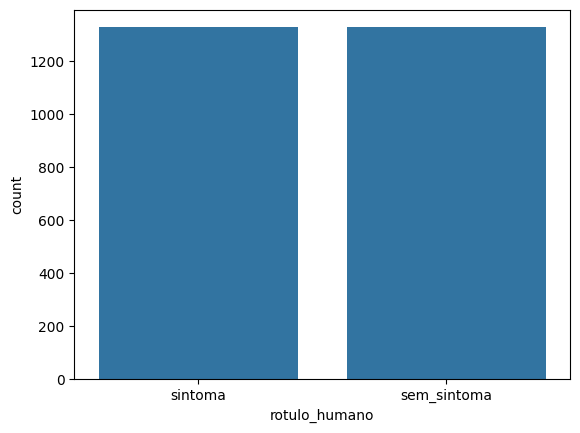

In [13]:
sns.countplot(x = data_process['rotulo_humano'])

<Axes: xlabel='classification', ylabel='count'>

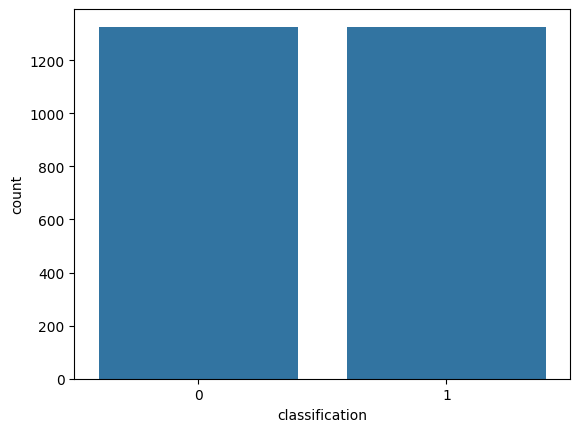

In [14]:
rus = RandomUnderSampler(random_state=0)
data_process["target"] = data_process["classification"]
X_bal, Y_bal = rus.fit_resample(data_process[['Texto']], data_process['classification'])
sns.countplot(x=Y_bal)

# Words cloud

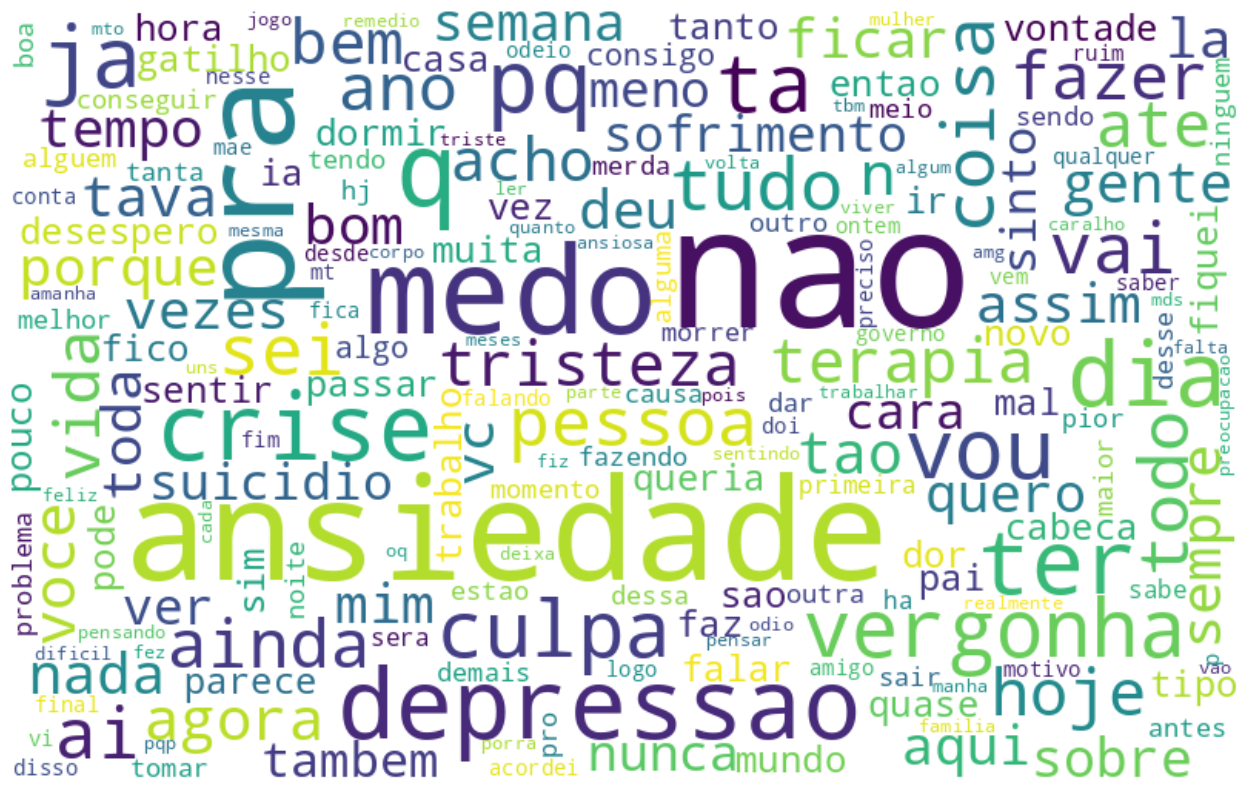

In [15]:
new_texts = data_process["Texto"]
all_words = ' '.join([text for text in new_texts])
word_cloud = WordCloud(width= 800, height= 500, max_font_size = 110, background_color="white", collocations = False).generate(all_words)
plt.figure(figsize=(20,10))
plt.imshow(word_cloud, interpolation='bilinear')
plt.axis("off")
plt.show()

# Cross validation: K-fold

In [16]:
train_df, test_df, train_label, test_label = train_test_split(X_bal, Y_bal, test_size=0.20, random_state=42)

In [17]:
train_df, valid_df, train_label, valid_label = train_test_split(train_df, train_label, test_size=0.20, random_state=42)

# Tokenization

Tokenization is a process for spliting raw texts into tokens, and encoding the tokens into numeric data.

To do this, we first initialize a ```BertTokenizer```

In [18]:
bert_large = 'neuralmind/bert-large-portuguese-cased'

PRETRAINED_LM = bert_large
tokenizer = BertTokenizer.from_pretrained(bert_large, do_lower_case=True)
tokenizer

tokenizer_config.json:   0%|          | 0.00/155 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

added_tokens.json:   0%|          | 0.00/2.00 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/648 [00:00<?, ?B/s]

BertTokenizer(name_or_path='neuralmind/bert-large-portuguese-cased', vocab_size=29794, model_max_length=1000000000000000019884624838656, is_fast=False, padding_side='right', truncation_side='right', special_tokens={'unk_token': '[UNK]', 'sep_token': '[SEP]', 'pad_token': '[PAD]', 'cls_token': '[CLS]', 'mask_token': '[MASK]'}, clean_up_tokenization_spaces=True, added_tokens_decoder={
	0: AddedToken("[PAD]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	100: AddedToken("[UNK]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	101: AddedToken("[CLS]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	102: AddedToken("[SEP]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	103: AddedToken("[MASK]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
}
)

Define a function for encoding:

In [19]:
def encode(docs):
    '''
    This function takes list of texts and returns input_ids and attention_mask of texts
    '''
    encoded_dict = tokenizer.batch_encode_plus(docs, add_special_tokens=True, max_length=128, padding='max_length',
                            return_attention_mask=True, truncation=True, return_tensors='pt')
    input_ids = encoded_dict['input_ids']
    attention_masks = encoded_dict['attention_mask']
    return input_ids, attention_masks

Use the ```encode``` functionto get input ids and attention masks of the datasets:

In [20]:
train_input_ids, train_att_masks = encode(train_df['Texto'].values.tolist())
valid_input_ids, valid_att_masks = encode(valid_df['Texto'].values.tolist())
test_input_ids, test_att_masks = encode(test_df['Texto'].values.tolist())

# Creating ```Datasets``` and ```DataLoaders```

We'll use pytorch ```Dataset``` and ```DataLoader``` to split data into batches. For more detatils, you can check out another post on DataLoader.


Turn the labels into tensors:

In [21]:
import torch
train_label.values
train_y = torch.LongTensor(train_label.values)
valid_y = torch.LongTensor(valid_label.values)
test_y = torch.LongTensor(test_label.values)
train_y.size(),valid_y.size(),test_y.size()

(torch.Size([1696]), torch.Size([425]), torch.Size([531]))

Create dataloaders for training

In [22]:
from torch.utils.data import TensorDataset, DataLoader, RandomSampler, SequentialSampler

BATCH_SIZE = 16
train_dataset = TensorDataset(train_input_ids, train_att_masks, train_y)
train_sampler = RandomSampler(train_dataset)
train_dataloader = DataLoader(train_dataset, sampler=train_sampler, batch_size=BATCH_SIZE)

valid_dataset = TensorDataset(valid_input_ids, valid_att_masks, valid_y)
valid_sampler = SequentialSampler(valid_dataset)
valid_dataloader = DataLoader(valid_dataset, sampler=valid_sampler, batch_size=BATCH_SIZE)

test_dataset = TensorDataset(test_input_ids, test_att_masks, test_y)
test_sampler = SequentialSampler(test_dataset)
test_dataloader = DataLoader(test_dataset, sampler=test_sampler, batch_size=BATCH_SIZE)

## Bert For Sequence Classification Model

We will initiate the  `BertForSequenceClassification ` model from Huggingface, which allows easily fine-tuning the pretrained BERT mode for classification task.


You will see a warning that some parts of the model are randomly initialized. This is normal since the classification head has not yet been trained.

In [23]:
train_label.unique()

array([1, 0])

In [24]:
from transformers import BertForSequenceClassification
N_labels = len(train_label.unique())
model = BertForSequenceClassification.from_pretrained(PRETRAINED_LM,
                                                      num_labels=N_labels,
                                                      output_attentions=False,
                                                      output_hidden_states=False)

pytorch_model.bin:   0%|          | 0.00/1.34G [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/1.34G [00:01<?, ?B/s]

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at neuralmind/bert-large-portuguese-cased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [25]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device


device(type='cuda')

In [26]:
model = model.to(device)

# Fine-tuning

## Optimizer and Scheduler

An **optimizer** is for tuning parameters in the model, which is set up with a learning rate.

Selection of the learning rate is important. In practice, it's common to use a **scheduler** to decrease the learning rate during training.

In [27]:
from torch.optim import AdamW
from transformers import get_linear_schedule_with_warmup

# Best results: 07 and 08
EPOCHS = 5
LEARNING_RATE = 2e-6

optimizer = AdamW(model.parameters(), lr=LEARNING_RATE)
scheduler = get_linear_schedule_with_warmup(optimizer,
             num_warmup_steps=0,
            num_training_steps=len(train_dataloader)*EPOCHS )

### **Training Loop**

The training loop is where the magic of deep learning happens. The model will be fine-tuned on the emotion dataset for classification task.

In [28]:
#collapse-output
from torch.nn.utils import clip_grad_norm_
from tqdm.notebook import tqdm
import numpy as np
import math

train_loss_per_epoch = []
val_loss_per_epoch = []

for epoch_num in range(EPOCHS):
    print('Epoch: ', epoch_num + 1)
    '''
    Training
    '''
    model.train()
    train_loss = 0
    for step_num, batch_data in enumerate(tqdm(train_dataloader, desc='Training')):
        input_ids, att_mask, labels = [data.to(device) for data in batch_data]

        output = model(input_ids=input_ids, attention_mask=att_mask, labels=labels)

        loss = output.loss
        train_loss += loss.item()

        model.zero_grad()
        loss.backward()
        del loss

        clip_grad_norm_(parameters=model.parameters(), max_norm=1.0)
        optimizer.step()
        scheduler.step()

    train_loss_per_epoch.append(train_loss / (step_num + 1))


    '''
    Validation
    '''
    model.eval()
    valid_loss = 0
    valid_pred = []
    with torch.no_grad():
        for step_num_e, batch_data in enumerate(tqdm(valid_dataloader, desc='Validation')):
            input_ids, att_mask, labels = [data.to(device) for data in batch_data]
            output = model(input_ids=input_ids, attention_mask=att_mask, labels=labels)

            loss = output.loss
            valid_loss += loss.item()

            valid_pred.append(np.argmax(output.logits.cpu().detach().numpy(), axis=-1))

    val_loss_per_epoch.append(valid_loss / (step_num_e + 1))
    valid_pred = np.concatenate(valid_pred)

    '''
    Loss message
    '''
    print("{0}/{1} train loss: {2} ".format(step_num+1, math.ceil(len(train_df) / BATCH_SIZE), train_loss / (step_num + 1)))
    print("{0}/{1} val loss: {2} ".format(step_num_e+1, math.ceil(len(valid_df) / BATCH_SIZE), valid_loss / (step_num_e + 1)))

Epoch:  1


Training:   0%|          | 0/106 [00:00<?, ?it/s]

Validation:   0%|          | 0/27 [00:00<?, ?it/s]

106/106 train loss: 0.6595672391495615 
27/27 val loss: 0.5943583868168019 
Epoch:  2


Training:   0%|          | 0/106 [00:00<?, ?it/s]

...

Validation:   0%|          | 0/27 [00:00<?, ?it/s]

106/106 train loss: 0.41729621069048933 
27/27 val loss: 0.36850702045140443 
Epoch:  5


Training:   0%|          | 0/106 [00:00<?, ?it/s]

Validation:   0%|          | 0/27 [00:00<?, ?it/s]

106/106 train loss: 0.375995767988124 
27/27 val loss: 0.3582767126736818 


You can see in the output that the training and validation losses steadily decreases in each epoch.

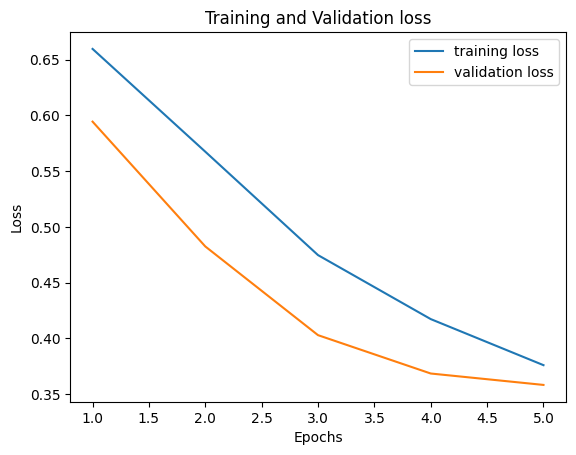

In [29]:
from matplotlib import pyplot as plt
epochs = range(1, EPOCHS+1)
fig, ax = plt.subplots()
ax.plot(epochs,train_loss_per_epoch,label ='training loss')
ax.plot(epochs, val_loss_per_epoch, label = 'validation loss' )
ax.set_title('Training and Validation loss')
ax.set_xlabel('Epochs')
ax.set_ylabel('Loss')
ax.legend()
plt.show()

## Performance Metrics
It's common to use precision, recall, and F1-score as the performance metrics.

In [30]:
label_names = ['sem sintoma', 'sintoma']
label_names

['sem sintoma', 'sintoma']

In [31]:
from sklearn.metrics import classification_report
print('classifiation report')
print(classification_report(valid_pred, valid_label.to_numpy(), target_names=label_names))

classifiation report
              precision    recall  f1-score   support

 sem sintoma       0.81      0.86      0.84       192
     sintoma       0.88      0.84      0.86       233

    accuracy                           0.85       425
   macro avg       0.85      0.85      0.85       425
weighted avg       0.85      0.85      0.85       425



## Error Analysis
With the predictions, we can plot the confusion matrix:

In [32]:
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix
def plot_confusion_matrix(y_preds, y_true, labels=None):
  cm = confusion_matrix(y_true, y_preds, normalize="true")
  fig, ax = plt.subplots(figsize=(6, 6))
  disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
  disp.plot(cmap="Blues", values_format=".2f", ax=ax, colorbar=False)
  plt.title("Normalized confusion matrix")
  plt.show()

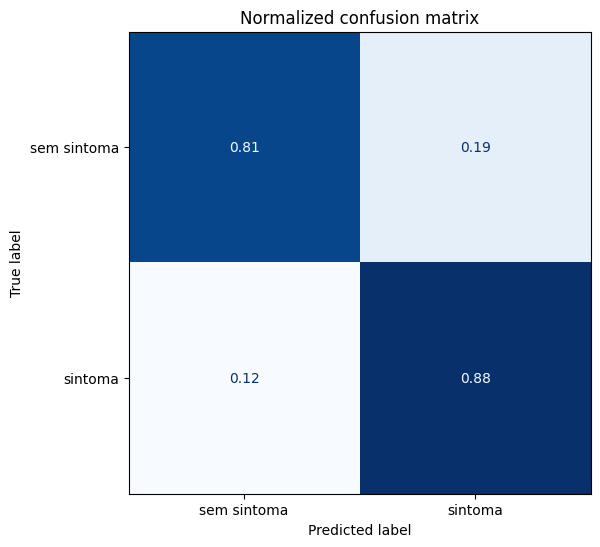

In [33]:
plot_confusion_matrix(valid_pred,valid_label.to_numpy(),labels=label_names)

## Prediction
Now let's use the trained model to predict the testing set.

In [34]:
model.eval()
test_pred = []
test_loss= 0
with torch.no_grad():
    for step_num, batch_data in tqdm(enumerate(test_dataloader)):
        input_ids, att_mask, labels = [data.to(device) for data in batch_data]
        output = model(input_ids = input_ids, attention_mask=att_mask, labels= labels)

        loss = output.loss
        test_loss += loss.item()

        test_pred.append(np.argmax(output.logits.cpu().detach().numpy(),axis=-1))
test_pred = np.concatenate(test_pred)

0it [00:00, ?it/s]

In [35]:
print('classifiation report')
print(classification_report(test_pred, test_label.to_numpy(),target_names=label_names))

classifiation report
              precision    recall  f1-score   support

 sem sintoma       0.74      0.86      0.80       229
     sintoma       0.88      0.77      0.82       302

    accuracy                           0.81       531
   macro avg       0.81      0.82      0.81       531
weighted avg       0.82      0.81      0.81       531



With the predictions, we can plot the confusion matrix again:

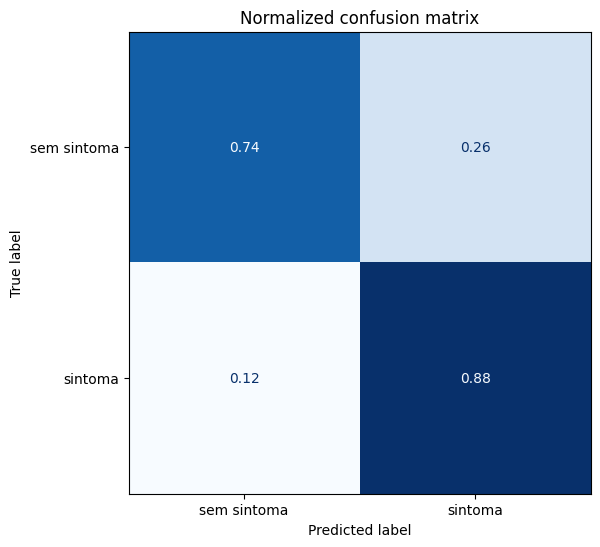

In [36]:
plot_confusion_matrix(test_pred,test_label.to_numpy(),labels=label_names)

Output the misclassified text:

In [37]:
test_df['pred'] = test_pred
test_df['label'] = test_label
test_df.reset_index(level=0)
print(test_df[test_df['label']!=test_df['pred']].shape)
test_df[test_df['label']!=test_df['pred']][['Texto','label','pred']].head(10)

(101, 3)


,Texto,label,pred
1499,hiperfoco davi nao deixa ter depressao,0,1
2111,tendo taquicardia tremores,0,1
316,ai sofrimento fim amg,1,0
2419,sinto cheguei momento vida preciso apoio terapia,0,1
63,hj so tristeza caos aqui infelizmente huahaus ...,1,0
1547,curtindo pouquinho sofrimento pra entreter dor,0,1
84,vou cortar nome pulso so pra ter ctz culpa,1,0
176,cancela suicidio,1,0
1824,pior epoca tomava vinho todo dia achava normal...,0,1
938,quero mae volte trabalhar logo hmhmmhmhm ai vo...,1,0


## **Salvando os resultados e o modelo binário do BERT**

In [38]:
import shutil

In [39]:
NAME_MODEL = 'BERT-Large'

test_df.to_csv(f"test_results_{NAME_MODEL}.csv", index=False)
shutil.copy(f'/content/test_results_{NAME_MODEL}.csv', f'/content/drive/MyDrive/test_results_{NAME_MODEL}')

MODEL_PATH = NAME_MODEL + ".bin"
torch.save(model.state_dict(), MODEL_PATH)

shutil.copy(f'/content/{MODEL_PATH}', f'/content/drive/MyDrive/{MODEL_PATH}')

'/content/drive/MyDrive/BERT-Large.bin'